In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

REPORT_DIR = (
    Path.home()
    / "projects"
    / "portfolio"
    / "project-00-spark-validation"
    / "reports"
)

pandas_runs = pd.read_csv(REPORT_DIR / "pandas_benchmark_runs.csv")
cudf_runs = pd.read_csv(REPORT_DIR / "cudf_benchmark_runs.csv")

print(pandas_runs.shape)
print(cudf_runs.shape)

(20, 11)
(20, 11)


In [2]:
timing_cols = [
    "load",
    "filter",
    "null_count",
    "groupby",
    "feature_engineering",
    "sort",
    "total",
]

In [3]:
pandas_median = (
    pandas_runs
    .groupby("tier")[timing_cols]
    .median()
)

cudf_median = (
    cudf_runs
    .groupby("tier")[timing_cols]
    .median()
)

pandas_median

,load,filter,null_count,groupby,feature_engineering,sort,total
tier,,,,,,,
12_months,0.981093,1.208007,0.585115,1.116749,1.840788,12.205858,17.934147
1_month,0.054136,0.088383,0.041669,0.080529,0.083966,0.551301,0.900813
3_months,0.238395,0.269875,0.135417,0.259533,0.404647,2.441759,3.742887
6_months,0.490152,0.593962,0.330870,0.561109,0.927046,6.142449,9.054365


In [4]:
cudf_median

,load,filter,null_count,groupby,feature_engineering,sort,total
tier,,,,,,,
12_months,1.091773,0.393350,0.137593,0.062991,0.633408,0.939807,3.259784
1_month,0.085836,0.034905,0.021809,0.008187,0.058900,0.062990,0.272826
3_months,0.261370,0.098757,0.046204,0.015917,0.158173,0.210733,0.792562
6_months,0.550388,0.200331,0.077854,0.031758,0.317399,0.457390,1.638407


In [6]:
#speedup > 1  → cuDF faster
#speedup = 1  → same speed
#speedup < 1  → pandas faster

speedup = pandas_median / cudf_median

speedup

,load,filter,null_count,groupby,feature_engineering,sort,total
tier,,,,,,,
12_months,0.898624,3.071074,4.252513,17.728805,2.906166,12.987627,5.501637
1_month,0.630693,2.532091,1.910652,9.836161,1.425572,8.752125,3.301790
3_months,0.912097,2.732709,2.930843,16.304964,2.558259,11.586996,4.722517
6_months,0.890558,2.964905,4.249896,17.668482,2.920756,13.429338,5.526323


In [7]:
#combined summary
summary = pd.DataFrame({
    "pandas_total_median": pandas_median["total"],
    "cudf_total_median": cudf_median["total"],
    "total_speedup": speedup["total"],
})

summary

,pandas_total_median,cudf_total_median,total_speedup
tier,,,
12_months,17.934147,3.259784,5.501637
1_month,0.900813,0.272826,3.301790
3_months,3.742887,0.792562,4.722517
6_months,9.054365,1.638407,5.526323


In [8]:
summary.to_csv(
    REPORT_DIR / "benchmark_comparison_summary.csv"
)

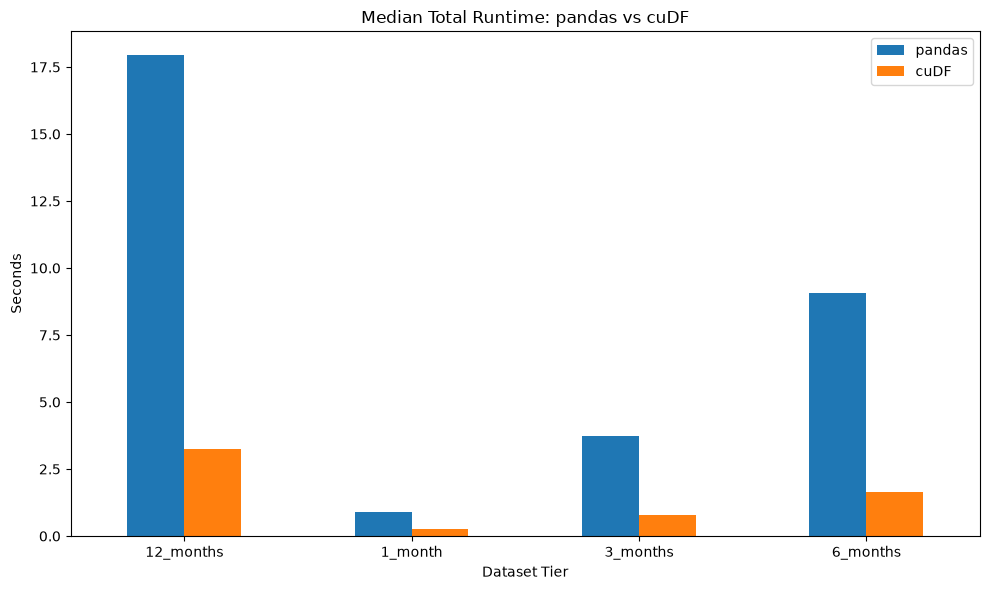

In [9]:
plot_df = pd.DataFrame({
    "pandas": pandas_median["total"],
    "cuDF": cudf_median["total"],
})

plot_df.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Median Total Runtime: pandas vs cuDF")
plt.ylabel("Seconds")
plt.xlabel("Dataset Tier")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

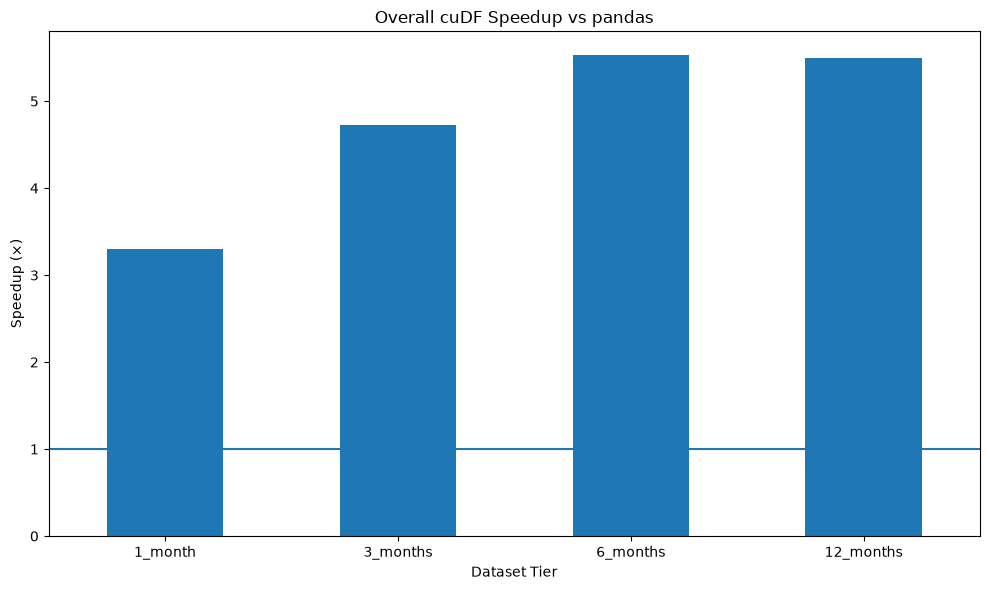

In [14]:
tier_order = [
    "1_month",
    "3_months",
    "6_months",
    "12_months"
]

speedup_ordered = speedup.loc[tier_order]

speedup_ordered["total"].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.axhline(1)
plt.title("Overall cuDF Speedup vs pandas")
plt.ylabel("Speedup (×)")
plt.xlabel("Dataset Tier")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

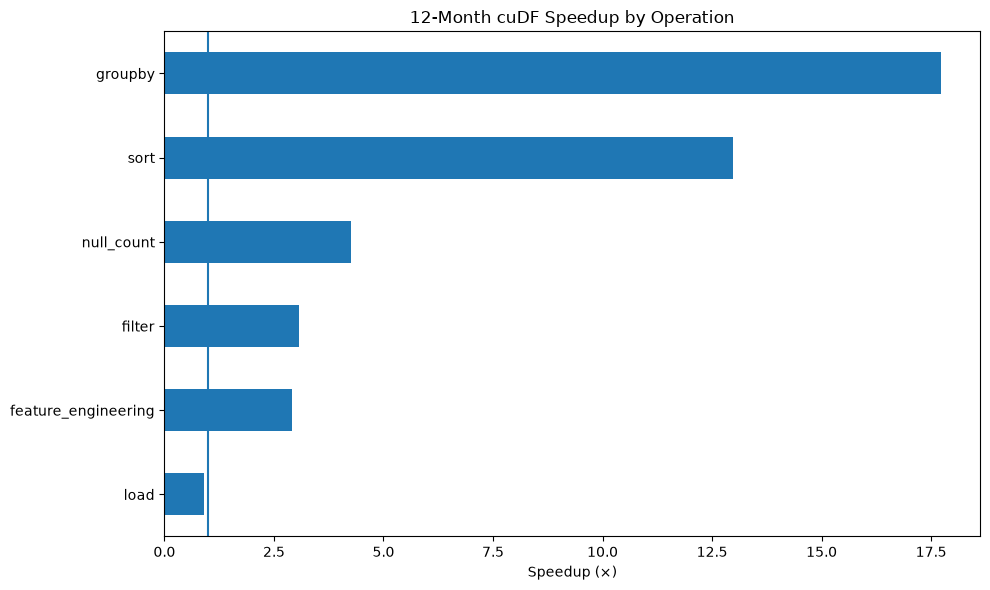

In [13]:
full_year_ops = speedup.loc["12_months", timing_cols[:-1]]

full_year_ops.sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.axvline(1)
plt.title("12-Month cuDF Speedup by Operation")
plt.xlabel("Speedup (×)")
plt.tight_layout()
plt.show()

In [15]:
FIGURE_DIR = REPORT_DIR / "figures"
FIGURE_DIR.mkdir(exist_ok=True)

In [16]:
plt.savefig(
    FIGURE_DIR / "12_month_operation_speedup.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [17]:
#cuDF’s advantage becomes substantial as the workload grows, but the size of that advantage depends heavily on the operation